# 医療費高騰に関係する因子を抽出する二値分類（TensorFlow/Keras）
本ノートブックは、Kaggle の *Medical Insurance Cost* データ（`insurance.csv`）を用いて、**医療費が高騰するか否か**を二値分類します。  
ディープラーニング（教師あり学習・二値分類・TensorFlow/Keras）を用い、**どの因子が医療費高騰に寄与しているか** を推定します。  
因果関係の主張ではなく、**統計的な関連性（寄与）** の解釈に留めます。

# 課題の要件を満たすため、まずはaccuracy > 0.5 を実現する。因子抽出はこれが出来てから着手します。

## 目的
- 目的変数: `charges` を二値化（上位25%を *High* クラス=1、それ以外=0）
- 手法: ディープラーニング（Keras）による二値分類
- 評価: ROC-AUC / PR-AUC / 混同行列 / 指標（Precision/Recall/F1）
- 重要度: 検証データでの **Permutation Importance** により因子寄与度を推定



## 0. セットアップ（ライブラリの準備）
Apple Silicon(M1/M2) の場合、TensorFlow は `pip install tensorflow-macos tensorflow-metal` が推奨です。CPU のみでも動作します。


In [13]:

# ユーティリティー
import os, sys, math, json, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 警告を除去してログを見やすくする
warnings.filterwarnings("ignore")

# 再現性確保のため
np.random.seed(42)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# モデル評価に用いる指標群
from sklearn.metrics import (
    roc_auc_score,                          # ROC曲線下面積（閾値に依存しない総合性能; 1.0に近いほど良い）
    average_precision_score,                # PR曲線の面積(AP, =AUC-PR)。陽性が希少なときの評価に強い
    roc_curve,                              # ROC用に FPR, TPR, thresholds を返す（最適閾値探索に利用）
    precision_recall_curve,                 # PR用に precision, recall, thresholds を返す
    confusion_matrix,                       # 閾値適用後の混同行列（TP, FP, TN, FN のカウント）
    classification_report                   # precision/recall/F1/support をクラス別・平均で整形出力
)

## 1. データ読み込み
アップロード済みの `insurance.csv` を読み込みます。列は `age, sex, bmi, children, smoker, region, charges` です。

In [14]:

DATA_PATH = Path("insurance.csv")  # この環境では既にアップロード済み
assert DATA_PATH.exists(), f"insurance.csv not found at {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
#print(df.head())
display(df.head())
print("Shape:", df.shape)
print(df.dtypes)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Shape: (1338, 7)
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


## 2. EDA（簡易）
- 欠損値の有無、基本統計量の確認
- 目的変数 `charges` の分布


Missing values per column:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


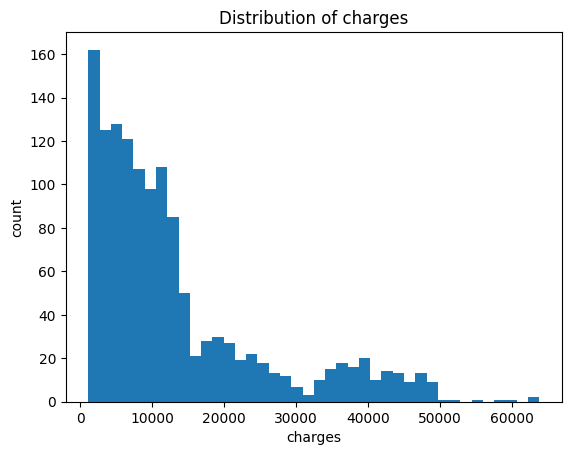

In [15]:

print("Missing values per column:\n", df.isna().sum())
display(df.describe(include='all'))

plt.figure()
plt.hist(df["charges"], bins=40)
plt.title("Distribution of charges")
plt.xlabel("charges")
plt.ylabel("count")
plt.show()


## 3. 目的変数を二値化（高コストフラグ）
上位25%（第75パーセンタイル）以上を `1: High`、それ未満を `0: Normal` とします。

In [16]:

# 医療費を75%で区切る
q75 = df["charges"].quantile(0.75)
# 医療費の75％以上(上位25%以上)であれば1、それ以外は0を格納する新しい列
df["target_high_cost"] = (df["charges"] >= q75).astype(int)

# 陽性(target_high_cost=1、医療費が上位25%以上)の比率
ratio = df["target_high_cost"].mean()

print(f"75%パーセンタイル: {q75:.2f}, 陽性比率: {ratio:.3f}")
df[["charges", "target_high_cost"]].head()


75%パーセンタイル: 16639.91, 陽性比率: 0.250


,charges,target_high_cost
0,16884.92400,1
1,1725.55230,0
2,4449.46200,0
3,21984.47061,1
4,3866.85520,0


## 4. 訓練・検証・テスト分割
層化分割（stratify）で 6:2:2 に分割します。

In [17]:
# stratify=df["target_high_cost"]でターゲット列が各値で同様の分布になるようにしている。
# これをしないと、例えば検証用val_dfで医療費が高騰している患者が極端に少ないという状況が発生し得る。

train_df, temp_df = train_test_split(
    df, test_size=0.4, random_state=42, stratify=df["target_high_cost"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df["target_high_cost"]
)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)


Train: (802, 8) Val: (268, 8) Test: (268, 8)


## 5. 前処理（エンコーディング/スケーリング）
- 数値: `age`, `bmi`, `children` は標準化
- カテゴリ: `sex`, `smoker`, `region` は One-Hot エンコーディング


In [18]:

NUM_COLS = ["age", "bmi", "children"]
CAT_COLS = ["sex", "smoker", "region"]
TARGET = "target_high_cost"

# 数値項目を標準化する準備
# 学習用のTrainデータのみ利用。検証・テストを使うと、以降のデータの学習と評価に影響が出る。
def preprocess_fit(train_df):
    scaler = StandardScaler().fit(train_df[NUM_COLS])
    #print(scaler)
    return scaler

# データを加工する
def preprocess_transform(df_, scaler):
    # 数値項目の標準化
    X_num = scaler.transform(df_[NUM_COLS])
    #print(X_num)
    # カテゴリデータをOne-Hotエンコーディング
    X_cat = pd.get_dummies(df_[CAT_COLS], drop_first=False)
    #print(X_cat)
    # 数値項目とカテゴリデータを結合
    X = np.hstack([X_num, X_cat.values])
    # 目的変数をTensorFlowに都合の良いint32にする
    y = df_[TARGET].values.astype(np.int32)

    # NumPy配列にすると列名データが消えるので、これで管理。
    feature_names = NUM_COLS + list(pd.get_dummies(df_[CAT_COLS], drop_first=False).columns)

    return X, y, feature_names

# 学習用データの処理
scaler = preprocess_fit(train_df)
X_train, y_train, feature_names = preprocess_transform(train_df, scaler)

# カテゴリ列のダミーがval/testでも同順になるように、trainの列順に合わせる。
def align_transform(df_, scaler, feature_names):

    X_num = scaler.transform(df_[NUM_COLS])
    X_cat_full = pd.get_dummies(df_[CAT_COLS], drop_first=False)

    #print(f"NUM_COLS:{NUM_COLS}")
    #print(f"len(NUM_COLS):{len(NUM_COLS)}")
    #print(f"X_cat_full:{X_cat_full}")
    #print(f"feature_names[len(NUM_COLS):]:{feature_names[len(NUM_COLS):]}")

    # カテゴリー列を追加、元あったの不要な列は削除する
    # get_dummiesでカテゴリー変数が出来ない場合を想定した処理
    for col in feature_names[len(NUM_COLS):]:
        
        #if col not in X_cat_full.columns and col not in NUM_COLS:
        if col not in X_cat_full.columns:
            X_cat_full[col] = 0
    # カテゴリー変数以外を削除
    X_cat_full = X_cat_full[[c for c in feature_names if c not in NUM_COLS]]

    X = np.hstack([X_num, X_cat_full.values])
    y = df_[TARGET].values.astype(np.int32)
    return X, y

# 検証&テスト用データの処理
X_val, y_val = align_transform(val_df, scaler, feature_names)
X_test, y_test = align_transform(test_df, scaler, feature_names)

print("X_train:", X_train.shape, "X_val:", X_val.shape, "X_test:", X_test.shape)
print("Features:", feature_names)
print(X_train[0])


X_train: (802, 11) X_val: (268, 11) X_test: (268, 11)
Features: ['age', 'bmi', 'children', 'sex_female', 'sex_male', 'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
[0.28710416 0.32666218 1.52147286 1.         0.         0.
 1.         0.         0.         1.         0.        ]


## 6. tf.data 
- ここでシャッフル/バッチ化などを明示する。model.fit()時ではなく、事前に定義しておく。
- Denceを使うので、説明変数はfloat32に変換しておく。

In [19]:

BATCH = 64
# 学習用データは順序によるバイアスを避けるためshuffleする。
train_ds = tf.data.Dataset.from_tensor_slices((X_train.astype("float32"), y_train)).shuffle(2048).batch(BATCH).prefetch(tf.data.AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val.astype("float32"), y_val)).batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test.astype("float32"), y_test)).batch(BATCH).prefetch(tf.data.AUTOTUNE)


## 7. モデル定義（Keras：二値分類 MLP）
- 入力: Dense → BatchNorm → ReLU → Dropout
- 出力: シグモイド
- 損失: BinaryCrossentropy, メトリクス: AUC(ROC/PR)


In [20]:

tf.keras.utils.set_random_seed(42)

# 学習データの項目数取得
n_features = X_train.shape[1]

# 入力層
inputs = keras.Input(shape=(n_features,), name="features")

# 隠れ層1
# 学習安定化のためkernel_initializerで初期値を指定する。
x = layers.Dense(64, kernel_initializer="he_normal")(inputs)
# 正規化。後続のActivationでの勾配爆発/消失を緩和する。
x = layers.BatchNormalization()(x)
# BatchNormalizationより前にReLUが適用されることを避けるため、Denseの中でReLUを指定せず、個別で指定する。
x = layers.Activation("relu")(x)
x = layers.Dropout(0.3)(x)

# 隠れ層2
x = layers.Dense(32, kernel_initializer="he_normal")(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.2)(x)

# 出力層
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs, name="high_cost_classifier")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.AUC(curve="ROC", name="AUC_ROC"),
        keras.metrics.AUC(curve="PR", name="AUC_PR"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
    ],
)
model.summary()


Model: "high_cost_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 192 (768.00 B)

## 8. 学習
- `EarlyStopping` と `ModelCheckpoint` を利用
- クラス不均衡に応じて `class_weight` を設定


class_weight: {0: np.float64(0.6672212978369384), 1: np.float64(1.9950248756218907)}
Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - AUC_PR: 0.2696 - AUC_ROC: 0.5412 - loss: 0.7666 - precision: 0.2734 - recall: 0.3930 - val_AUC_PR: 0.4313 - val_AUC_ROC: 0.6762 - val_loss: 0.5384 - val_precision: 0.5000 - val_recall: 0.2836
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC_PR: 0.4041 - AUC_ROC: 0.6758 - loss: 0.6462 - precision: 0.3571 - recall: 0.5970 - val_AUC_PR: 0.5988 - val_AUC_ROC: 0.7653 - val_loss: 0.4893 - val_precision: 0.7407 - val_recall: 0.2985
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC_PR: 0.5360 - AUC_ROC: 0.7661 - loss: 0.5865 - precision: 0.4399 - recall: 0.7463 - val_AUC_PR: 0.7362 - val_AUC_ROC: 0.8209 - val_loss: 0.4543 - val_precision: 0.9286 - val_recall: 0.3881
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC_PR: 0.6822 - AUC_ROC: 0.8255 - loss: 0.5357 - precision: 0.4802 - recall: 0.7861 - val_AUC_PR: 0.7910 - val_AUC_ROC: 0.841

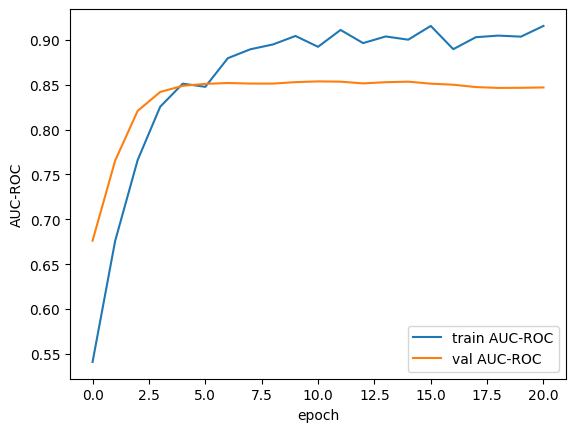

In [ ]:

# class_weights

# 陽性率計算 y_trainは二値(0,1)なので平均が陽性(=1)の割合になる。
pos_ratio = y_train.mean()
# 目的変数(0,1)の重み計算 
# クラス不均衡対策：class_weightで損失の寄与を陽性/陰性で均等化し、少数クラスが無視されるのを防ぐ。
# 今回は陽性が25%なので、影響を考慮した。
w_pos = 0.5 / pos_ratio
w_neg = 0.5 / (1.0 - pos_ratio)
class_weight = {0: w_neg, 1: w_pos}
print("class_weight:", class_weight)

#ckpt_path = "/mnt/data/best_model.keras"
ckpt_path = "best_model.keras"
# AUC_ROCを指標にする。EarlyStoppingとモデル保存を同時に行う。
callbacks = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor="val_AUC_ROC", mode="max"),
    keras.callbacks.ModelCheckpoint(ckpt_path, monitor="val_AUC_ROC", mode="max", save_best_only=True),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=callbacks,
    class_weight=class_weight,
    verbose=1
)

# 学習曲線
plt.figure()
plt.plot(history.history["AUC_ROC"], label="train AUC-ROC")
plt.plot(history.history["val_AUC_ROC"], label="val AUC-ROC")
plt.xlabel("epoch"); plt.ylabel("AUC-ROC"); plt.legend(); plt.show()


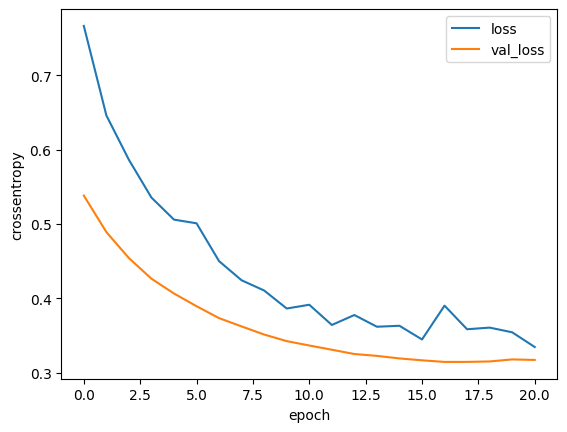

In [24]:
# 学習曲線
plt.figure()
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("crossentropy"); plt.legend(); plt.show()

上記の評価
- train_AUCとvalAUCの乖離が継続しており過学習っぽいが、va_lossが単調減少しているので問題無しと判断。
- 数エポックで性能が頭打ち→EarlyStopping/Checkpointで最良点を確保していそう。
- 監視指標のval_AUC_ROCは安定している。
- val_AUC_ROCがおおよそ0.85あたりで推移している。これはランダムに選んだ陽性(医療費高(上位25%))の医療費が陰性より高い確率が85%だということ。
- 上記により、このモデルは妥当だと判断する。

## 9. 評価（テストデータ）
- ROC-AUC / PR-AUC
- 混同行列 / Precision / Recall / F1 / サマリー
- ROC:モデル全体の識別力チェック（しきい値に依存しない）
- PR:陽性検出の実務適合性チェック（事前確率を基準に評価）
- AUCは“モデル全体の当て具合”を1つの数字で表す便利な要約値で、ROC-AUCはランキング性能、PR-AUCは陽性検出を特に捉えます。

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test ROC-AUC: 0.863, PR-AUC: 0.850


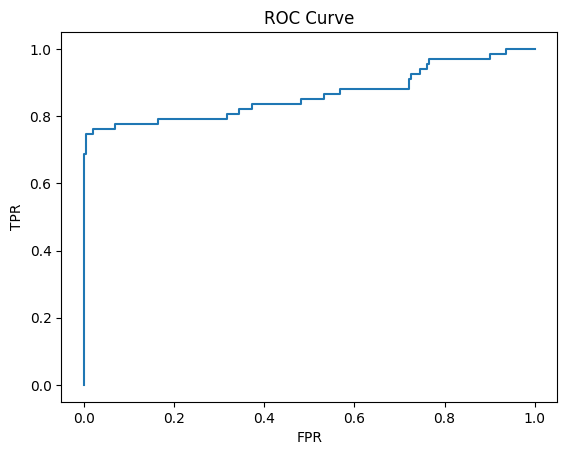

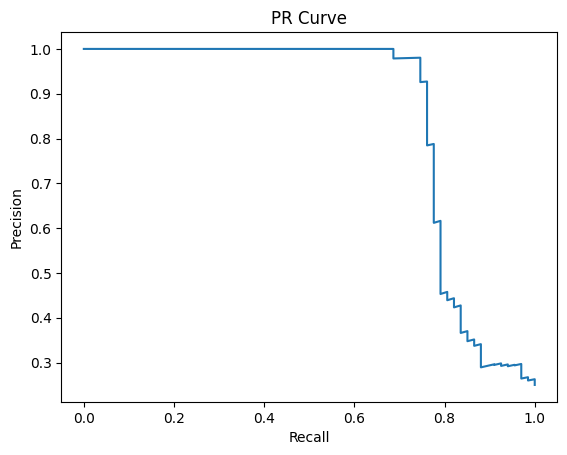

Best threshold (Youden's J): 0.612
Confusion Matrix:
 [[200   1]
 [ 17  50]]
              precision    recall  f1-score   support

           0      0.922     0.995     0.957       201
           1      0.980     0.746     0.847        67

    accuracy                          0.933       268
   macro avg      0.951     0.871     0.902       268
weighted avg      0.936     0.933     0.930       268



In [26]:

# 予測確率
y_pred_proba = model.predict(test_ds).ravel()
auc = roc_auc_score(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)
print(f"Test ROC-AUC: {auc:.3f}, PR-AUC: {ap:.3f}")

# ROC / PR 曲線
fpr, tpr, roc_th = roc_curve(y_test, y_pred_proba)
prec, rec, pr_th = precision_recall_curve(y_test, y_pred_proba)

# TPR = TP / (TP + FN) … 本当に陽性の中で当てられた割合
# FPR = FP / (FP + TN) … 本当は陰性なのに陽性と誤判定した割合

plt.figure(); plt.plot(fpr, tpr); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.show()
plt.figure(); plt.plot(rec, prec); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR Curve"); plt.show()

# 最適閾値（Youden's J）で二値化
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_th = roc_th[best_idx]
print(f"Best threshold (Youden's J): {best_th:.3f}")

y_pred = (y_pred_proba >= best_th).astype(int)
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
"""
TP（真陽性）：陽性を陽性と判定
FP（偽陽性）：陰性を陽性と誤判定
FN（偽陰性）：陽性を陰性と誤判定
TN（真陰性）：陰性を陰性と判定
"""
print(classification_report(y_test, y_pred, digits=3))


上記の評価
- ROC-AUC：0.863
  - 陽性（上位25%）のスコアが陰性より高い確率が 86.3%で十分に良好。
- PR-AUC: 0.850
  - classification_reportによるとクラス0=201,クラス1=67で陽性(クラス1)の確率は0.25。これを上回っているので良好。

# accuracy:0.933
  - **正解率50%以上を達成**


## 10. 因子の寄与度（Permutation Importance, 検証データ）
各特徴を入れ替えたときの **AUC-ROC の低下量** を重要度と定義します。値が大きいほど寄与が大きいと解釈します。


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


,feature,importance_auc_drop
0,smoker_no,0.062033
1,smoker_yes,0.045311
2,bmi,0.009906
3,age,0.009044
4,region_northeast,0.008762
5,region_southwest,0.007292
6,children,0.007129
7,sex_female,0.002718
8,region_northwest,0.002569
9,sex_male,-0.000624


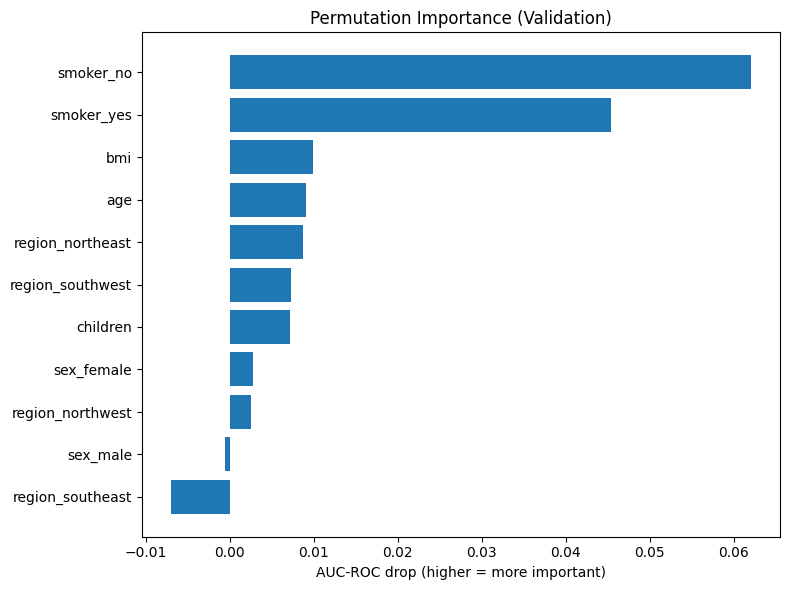

In [ ]:

def permutation_importance_auc(model, X, y, n_repeats=5, batch=256, seed=42):
    rng = np.random.RandomState(seed)
    # 比較対象となる基準AUCを計算
    base_proba = model.predict(X, batch_size=batch).ravel()
    base_auc = roc_auc_score(y, base_proba)

    importances = []

    for j in range(X.shape[1]):
        deltas = []
        for _ in range(n_repeats):
            # 元データへの影響を防ぐためコピー
            X_perm = X.copy()
            # jで指定した列の値をシャッフルして、その行の目的変数との関係を破壊
            rng.shuffle(X_perm[:, j])
            # シャッフルしたデータでAUCを求める
            proba = model.predict(X_perm, batch_size=batch).ravel()
            auc = roc_auc_score(y, proba)
            # 基準AUCとの差分を出す
            deltas.append(base_auc - auc)
        importances.append(np.mean(deltas))
    return np.array(importances), base_auc

# モデル学習時のデータ型にする
Xv_np = X_val.astype("float32")

# AUC差分計算実行
# valデータを使うことで、より汎化した評価ができる
imp_vals, base_auc = permutation_importance_auc(model, Xv_np, y_val, n_repeats=5)

# データ整形
imp_df = pd.DataFrame({"feature": feature_names, "importance_auc_drop": imp_vals})
imp_df = imp_df.sort_values("importance_auc_drop", ascending=False).reset_index(drop=True)
display(imp_df.head(20))

# グラフ化
plt.figure(figsize=(8, 6))
plt.barh(imp_df["feature"][:15][::-1], imp_df["importance_auc_drop"][:15][::-1])
plt.xlabel("AUC-ROC drop (higher = more important)")
plt.title("Permutation Importance (Validation)")
plt.tight_layout()
plt.show()


上記の評価
- 喫煙が基準AUCとの差分が大きい
- このグラフを見る限り、喫煙が医療費の高騰との関連性が高いことが窺える。

## 11. モデルとスケーラの保存


In [28]:
"""
model.save("/mnt/data/high_cost_classifier.keras")
import joblib
joblib.dump(scaler, "/mnt/data/standard_scaler.joblib")
with open("/mnt/data/feature_names.json", "w") as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)
print("Artifacts saved to /mnt/data")
"""

model.save("high_cost_classifier.keras")
import joblib
joblib.dump(scaler, "standard_scaler.joblib")
with open("feature_names.json", "w") as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)
print("Artifacts saved to /mnt/data")




Artifacts saved to /mnt/data
